In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("netflix_titles.csv", encoding="latin1")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print(df.shape)

(8807, 12)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
print(numerical_cols)

Index(['release_year'], dtype='str')


In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


C:\Users\Admin\AppData\Local\Temp\ipykernel_11116\358451199.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [8]:
for col in df.columns:
    print(col, ":", df[col].nunique())

show_id : 8807
type : 2
title : 8804
director : 4528
cast : 7692
country : 748
date_added : 1767
release_year : 74
rating : 17
duration : 220
listed_in : 514
description : 8775


In [9]:
df['show_id'].nunique()

8807

## Dataset numerical columns include: release_year
## Dataset categorical columns include:showID,type,title,director,cast,country,date added,rating,duration,listed_in and description
## UniqueID was identified

In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

The following columns contained missing values:
- director
- cast
- country
- date_added
- rating
- duration

In [11]:
df['director'] = df['director'].fillna('Unknown')

In [12]:
df['cast'] = df['cast'].fillna('Not Available')

In [13]:
df['country'] = df['country'].fillna('Unknown')

In [14]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [15]:
df = df.dropna(subset=['duration'])

In [16]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [17]:
df = df.dropna(subset=['date_added'])

In [18]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Missing values were handled using the appropriate methods

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['date_added'] = pd.to_datetime(df['date_added'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_11116\2944776423.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'])


In [21]:
df['date_added'].dtype

dtype('<M8[us]')

In [22]:
df.columns = df.columns.str.lower()

In [23]:
df['type'] = df['type'].str.title()

In [24]:
df['type'].unique()

<StringArray>
['Movie', 'Tv Show']
Length: 2, dtype: str

## Cleaning Summary Table
| Issue Found | Action Taken |
|-------------|--------------|
| Missing director values | Filled with "Unknown" |
| Missing cast values | Filled with "Not Available" |
| Missing country values | Filled with "Unknown" |
| Missing rating values | Filled using mode |
|Missing date_added values | Removed rows |
| Missind duration values | Removed rows |
| Duplicate records | No duplicates|
| Date format inconsistency | Converted to datetime |
| Column name formatting | Standardized to lowercase |
| Text formating | Standardized where necessary |

In [25]:
df.to_csv("Cleaned_netflix_titles.csv",index=False)

In [26]:
df.describe()

,date_added,release_year
count,8794,8794.000000
mean,2019-05-17 13:29:44.034569,2014.183534
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.823527


In [27]:
print(df['type'].mode())
print(df['rating'].mode())
print(df['country'].mode())

0    Movie
Name: type, dtype: str
0    TV-MA
Name: rating, dtype: str
0    United States
Name: country, dtype: str


In [28]:
df['type'].value_counts()

type
Movie      6128
Tv Show    2666
Name: count, dtype: int64

The dataset contains both movies and TV shows. The distribution was analysed to determine which content type is more common

In [29]:
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

Content additions were analysed by year to identify growth trends on Netflix

In [30]:
df['country'].value_counts().head(10)

country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

Countries were ranked based on the number of titles produced

In [31]:
df['rating'].value_counts().head(10)

rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

Content ratings were analysed to determine the most common audience classifications

In [32]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

Genre categories were examined to identify the most frequent content categories

In [33]:
import matplotlib.pyplot as plt

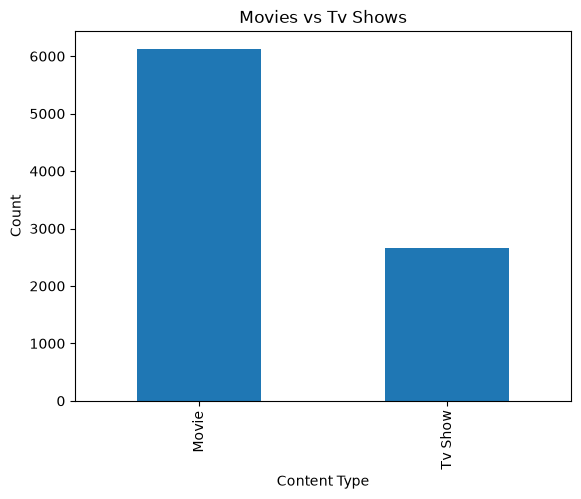

In [34]:
df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs Tv Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

Findings: The chart shows that Movies are more common on Netflix than Tv Shows, it makes up the majority of Netflix's content library.these indicates Netflix's stronger focus on film content

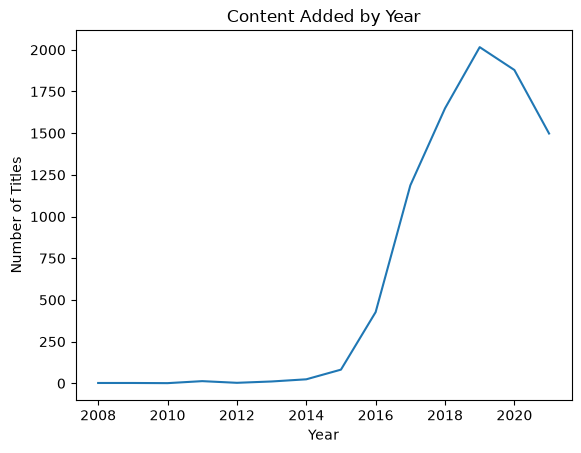

In [35]:
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title('Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

The number of titles added to Netflix remained relatively low from 2008 to 2014. content additions increased significantly from 2015 onward, reaching a peak in 2019. A decline was onserved in 2020 and 2021, although the number of addition remained substantially higher than in earlier years.

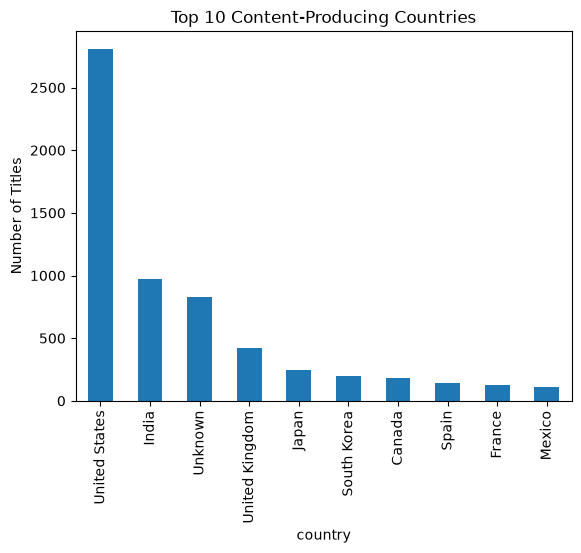

In [36]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('country')
plt.ylabel('Number of Titles')
plt.show()

The United states produced the largest number of Netflix titles, followed by India and the United Kingdom. other countries such as Japan, South Korea, Canada, Spain, France and Mexico also contribute on Netflix's global content library.

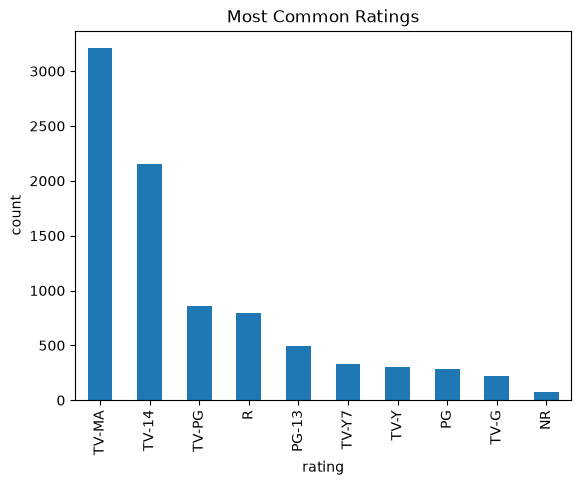

In [37]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Most Common Ratings')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()

TV-MA and TV_14 are have the most common ratings 

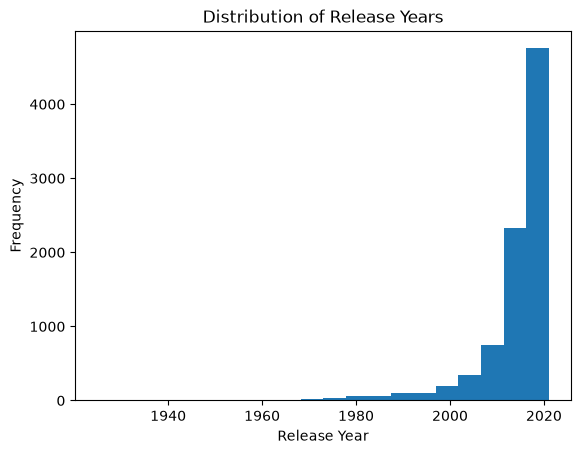

In [40]:
plt.hist(df['release_year'], bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

Most Netflix content were released in recent years,especially after 2010. very few titles originate from earlier decades

# Insights
1. Movies account for more than twice the number of TV Shows on Netflix. This suggests that netflix invests heavily in acuiring and producing movie content to cater to a broad audience.
2. The prevalence of TV-MA and TV-14 ratings indicates that Netflix primarily caters to teeneage and adult audience. This suggests a strong focus on mature entertainment, including dramas, thrillers,documentaries and other other content intended for older viewers
3. Netflix experienced its fastest period of content expansion between 2015 and 2019. The number of titles added increased dramatically during these years, indicating aggressive investment in content acquisition and production.
4. The United States dominates Netflix's catalog, contributing far more titles than any other country. India ranks second demonstrating the growing popularity of international content. Netflix's content comes from multiple regions,showing its commitment to serving a global audience.
5. Netflix's content library is dominated by modern releases. The high concentration of titles from the 2010s and 2020s suggests that the platform prioritizes recent and contemporary content to meet current viewer demand. 

# SUMMARY REPORT
# Data cleaning challenges
1. Missing values were contained in the important columns like in the director, cast, country, date_added,rating and durations columns
2. Converting the date_added column to datetime format generated parsing warnings that required validation
3. Some categorical columns contained incomplete information that need careful handling
# Key EDA Findings
1. Movies significantly outnumber TV Shows on Netflix
2. Content additions increased rapidly between 2015 and 2020
3. The United States contibuted the highest number of titles, followed by India
4. Most content available on Netflix was released after 2010
5. TV-MA and TV-14 had the highest ratings
# Top Insights
1. Movies dominate Netflix's library, accounting for more than twice the number of TV shows
2. Netflix experienced substiantial growth in content additions from 2015, reaching its highest levels around 2019-2020
3. The United States is the largest content-producing country on the platform, while India is the second-largest contributor
4. Most Netfli titles were released after 2010, indicating a strong preference for recent content.
5. TV-MA and TV-14 are the most common ratings, indicating that netflix primarily targets teenage and adult audience.
# Conclusion
These findings provide valuable insights into Netflix's content strategy and growth over time.